In [1]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install seaborn


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [5]:
# Data ingestion - Read and storing data in a variable
df= pd.read_csv('heart disease classification dataset.csv')
df.head()

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,male,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,yes
1,1,37,male,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,yes
2,2,41,female,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,yes
3,3,56,male,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,yes
4,4,57,female,0,NaN,354.0,0,1,163.0,1,0.6,2,0,2,yes


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  303 non-null    int64  
 1   age         303 non-null    int64  
 2   sex         303 non-null    str    
 3   cp          303 non-null    int64  
 4   trestbps    299 non-null    float64
 5   chol        302 non-null    float64
 6   fbs         303 non-null    int64  
 7   restecg     303 non-null    int64  
 8   thalach     298 non-null    float64
 9   exang       303 non-null    int64  
 10  oldpeak     303 non-null    float64
 11  slope       303 non-null    int64  
 12  ca          303 non-null    int64  
 13  thal        303 non-null    int64  
 14  target      303 non-null    str    
dtypes: float64(4), int64(9), str(2)
memory usage: 37.8 KB


In [7]:
# remove unnamed
df = df.drop('Unnamed: 0', axis=1)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,male,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,yes
1,37,male,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,yes
2,41,female,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,yes
3,56,male,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,yes
4,57,female,0,NaN,354.0,0,1,163.0,1,0.6,2,0,2,yes


In [8]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    4
chol        1
fbs         0
restecg     0
thalach     5
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

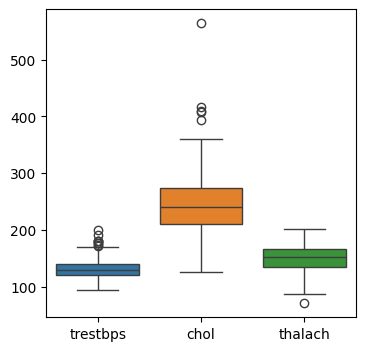

In [9]:
# Create boxplot of numerical column with missing values
plt.figure(figsize=(4,4))
sns.boxplot(data=df[['trestbps','chol','thalach']])
plt.show()


In [10]:
# Fill missing values in all 3 columns by their respective median
df['trestbps'] = df['trestbps'].fillna(df['trestbps'].median())
df['chol'] = df['chol'].fillna(df['chol'].median())
df['thalach'] = df['thalach'].fillna(df['thalach'].median())
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [11]:
# object/string to numerical column
# string to object
df['sex'] = df['sex'].astype(object)

In [12]:
# object to nummeric
#fisrt value of sex =male ,male-true
df=pd.get_dummies(df,columns=["sex"],drop_first=True)
df

,age,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,sex_male
0,63,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,yes,True
1,37,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,yes,True
2,41,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,yes,False
3,56,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,yes,True
4,57,0,130.0,354.0,0,1,163.0,1,0.6,2,0,2,yes,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,140.0,241.0,0,1,123.0,1,0.2,1,0,3,no,False
299,45,3,110.0,264.0,0,1,132.0,0,1.2,1,0,3,no,True
300,68,0,144.0,193.0,1,1,141.0,0,3.4,1,2,3,no,True
301,57,0,130.0,131.0,0,1,115.0,1,1.2,1,1,3,no,True


In [13]:
# object/string to numerical column
# string to object
df['target'] = df['target'].astype(object)

In [14]:
# checking category of target column
df['target'].value_counts()

target
yes    165
no     138
Name: count, dtype: int64

In [15]:
#convert non numerical column into numerical ones
df["target"]=df["target"].map({"yes":1,"no":0})
df.head()

,age,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,sex_male
0,63,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,1,True
1,37,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,1,True
2,41,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,1,False
3,56,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,1,True
4,57,0,130.0,354.0,0,1,163.0,1,0.6,2,0,2,1,False


In [16]:
# splitting x and y
X=df.drop("target",axis=1)
y=df["target"]

In [17]:
X

,age,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,sex_male
0,63,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,True
1,37,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,True
2,41,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,False
3,56,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,True
4,57,0,130.0,354.0,0,1,163.0,1,0.6,2,0,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,140.0,241.0,0,1,123.0,1,0.2,1,0,3,False
299,45,3,110.0,264.0,0,1,132.0,0,1.2,1,0,3,True
300,68,0,144.0,193.0,1,1,141.0,0,3.4,1,2,3,True
301,57,0,130.0,131.0,0,1,115.0,1,1.2,1,1,3,True


In [18]:
y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

In [19]:
# Extracting train and test data from x and y


X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [20]:

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
# convert back to data frame
X_train_scaled=pd.DataFrame(X_train_scaled, columns=X_train.columns)
print(X_train_scaled)
X_test_scaled=pd.DataFrame(X_test_scaled, columns=X_test.columns)

          age        cp  trestbps      chol  fbs  restecg   thalach  exang  \
0    0.270833  0.333333  0.265306  0.378753  0.0      0.5  0.649123    0.0   
1    0.604167  0.000000  0.571429  0.321016  0.0      0.0  0.201754    1.0   
2    0.354167  0.666667  0.571429  0.230947  0.0      0.5  0.517544    0.0   
3    0.541667  0.333333  0.418367  0.274827  0.0      0.0  0.640351    0.0   
4    0.645833  0.000000  0.234694  0.228637  1.0      0.5  0.631579    1.0   
..        ...       ...       ...       ...  ...      ...       ...    ...   
237  0.437500  0.666667  0.469388  0.235566  0.0      0.5  0.657895    0.0   
238  0.458333  0.666667  0.000000  0.221709  0.0      0.5  0.578947    1.0   
239  0.833333  1.000000  0.673469  0.237875  1.0      0.0  0.377193    0.0   
240  0.354167  0.000000  0.265306  0.272517  0.0      0.0  0.491228    0.0   
241  0.708333  0.333333  0.469388  0.147806  0.0      0.5  0.798246    0.0   

      oldpeak  slope    ca      thal  sex_male  
0    0.000000 

In [22]:
 # Model selection
models={
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "Naive Bayes": GaussianNB(),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest":RandomForestClassifier(random_state=42)
}

In [23]:
# Training and Testing all models
results ={}
for name, model in models.items():
    print(f"\n========={name}------")

# use scaled data only for logistic regression and naive bayes 
    if name in ["Logistic Regression","Naive Bayes"]:
        model.fit(X_train_scaled,y_train)
        y_pred= model.predict(X_test_scaled)
    else:
        model.fit(X_train,y_train)
        y_pred= model.predict(X_test)
    acc= accuracy_score(y_test,y_pred)
    pre=precision_score(y_test,y_pred)
    rec=recall_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    results[name]=[acc, pre, rec, f1]
    print("Accuracy :",acc)
    print("Precision :",pre)
    print("Recall :",rec)
    print("F1 Score :",f1)
    results_df=pd.DataFrame(results,index=["Accuracy","Precision","Recall","F1 Score"]).T
    print(results_df)
    ##results_df


=========LogisticRegression------
Accuracy : 0.8524590163934426
Precision : 0.8709677419354839
Recall : 0.84375
F1 Score : 0.8571428571428571
                    Accuracy  Precision   Recall  F1 Score
LogisticRegression  0.852459   0.870968  0.84375  0.857143

=========Naive Bayes------
Accuracy : 0.8688524590163934
Precision : 0.9
Recall : 0.84375
F1 Score : 0.8709677419354839
                    Accuracy  Precision   Recall  F1 Score
LogisticRegression  0.852459   0.870968  0.84375  0.857143
Naive Bayes         0.868852   0.900000  0.84375  0.870968

=========DecisionTree------
Accuracy : 0.819672131147541
Precision : 0.8620689655172413
Recall : 0.78125
F1 Score : 0.819672131147541
                    Accuracy  Precision   Recall  F1 Score
LogisticRegression  0.852459   0.870968  0.84375  0.857143
Naive Bayes         0.868852   0.900000  0.84375  0.870968
DecisionTree        0.819672   0.862069  0.78125  0.819672

=========RandomForest------
Accuracy : 0.8360655737704918
Precision :

In [24]:
# Checking best ML model for the data
best_model_name = results_df["Recall"].idxmax()
print("Best model based on Recall:", best_model_name)
best_model = models[best_model_name]

if best_model_name in ["Logistic Regression", "Naive Bayes"]:
    best_model.fit(X_train_scaled, y_train)
else:
    best_model.fit(X_train, y_train)

with open("model.pkl", "wb") as f:
    pickle.dump(best_model, f)

if best_model_name in ["Logistic Regression", "Naive Bayes"]:
    with open("scaler.pkl", "wb") as f:
        pickle.dump(scaler, f)

Best model based on Recall: LogisticRegression
